In [31]:
# Cell 2: Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

In [32]:
# Cell 3: Load dataset
url = "../datasets/PhiUSIIL_Phishing_URL_Dataset.csv"
df = pd.read_csv(url)

print("✅ Dataset loaded!")
print("Shape:", df.shape)
print("\nLabel distribution:")
print(df['label'].value_counts().sort_index())
print("→ 0 = Phishing (Malicious)")
print("→ 1 = Legitimate (Benign)")

✅ Dataset loaded!
Shape: (235795, 56)

Label distribution:
label
0    100945
1    134850
Name: count, dtype: int64
→ 0 = Phishing (Malicious)
→ 1 = Legitimate (Benign)


In [33]:
# Cell 4: Feature Selection (correct column names)
features = [
    'URLLength',
    'DomainLength',
    'NoOfSubDomain',
    'IsDomainIP',
    'IsHTTPS',
    'NoOfDegitsInURL',
    'NoOfOtherSpecialCharsInURL',
    'NoOfEqualsInURL',
    'NoOfQMarkInURL',
    'NoOfAmpersandInURL',
    'SpacialCharRatioInURL',
    'LetterRatioInURL',
    'DegitRatioInURL',
    'NoOfLettersInURL',
    'TLDLength'
]

X = df[features].copy()
y = df['label']   # 0 = Phishing, 1 = Legitimate

print(f"✅ Selected {len(features)} lexical features for real-time extraction")
print("Features:", features)

✅ Selected 15 lexical features for real-time extraction
Features: ['URLLength', 'DomainLength', 'NoOfSubDomain', 'IsDomainIP', 'IsHTTPS', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'SpacialCharRatioInURL', 'LetterRatioInURL', 'DegitRatioInURL', 'NoOfLettersInURL', 'TLDLength']


In [34]:
# Cell 5: Train-Test Split
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (188636, 15)
Testing set: (47159, 15)


In [44]:
# Cell 6: Train models + Prepare for ONNX export (Correct feature name fix)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                              random_state=42, n_jobs=-1, eval_metric='logloss')

print("Training models...")
rf.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Correct way to reset feature names for ONNX export (XGBoost compatible)
booster = xgb_model.get_booster()
booster.feature_names = [f"f{i}" for i in range(len(features))]

print("✅ Both models trained.")
print("✅ XGBoost feature names reset to f0, f1, ..., f14 for ONNX export.")

Training models...
✅ Both models trained.
✅ XGBoost feature names reset to f0, f1, ..., f14 for ONNX export.


=== PhishShield Ensemble (RF + XGBoost Soft Voting) Results ===
Accuracy : 0.9972
Precision: 0.9954
Recall   : 0.9997
F1-Score : 0.9975

Classification Report:
                 precision    recall  f1-score   support

  Phishing (0)       1.00      0.99      1.00     20189
Legitimate (1)       1.00      1.00      1.00     26970

      accuracy                           1.00     47159
     macro avg       1.00      1.00      1.00     47159
  weighted avg       1.00      1.00      1.00     47159



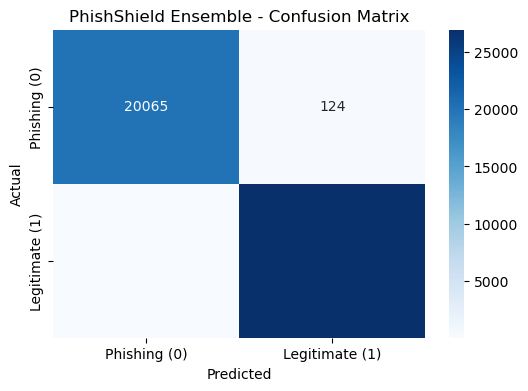

In [36]:
# Cell 7: Evaluation with manual soft voting
def ensemble_predict_proba(X):
    rf_proba = rf.predict_proba(X)
    xgb_proba = xgb_model.predict_proba(X)
    # Soft voting with slight weight to XGBoost
    return (rf_proba + 1.2 * xgb_proba) / (1 + 1.2)

y_proba = ensemble_predict_proba(X_test)
y_pred = (y_proba[:, 1] >= 0.5).astype(int)

print("=== PhishShield Ensemble (RF + XGBoost Soft Voting) Results ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-Score :", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:\n", 
      classification_report(y_test, y_pred, target_names=['Phishing (0)', 'Legitimate (1)']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Phishing (0)', 'Legitimate (1)'],
            yticklabels=['Phishing (0)', 'Legitimate (1)'])
plt.title('PhishShield Ensemble - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [48]:
# Cell 8: FIXED Export - Force probabilities for Random Forest
print("Exporting models with probability output...")

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

initial_type = [('float_input', FloatTensorType([None, len(features)]))]

# Important: Tell the converter to return probabilities
options = {type(rf): {'zipmap': False}}   # This forces probability output

onnx_rf = convert_sklearn(rf, 
                          initial_types=initial_type, 
                          target_opset=12,
                          options=options)   # ← Key fix

with open("phishshield_rf.onnx", "wb") as f:
    f.write(onnx_rf.SerializeToString())

print("✅ Random Forest exported with probability output: phishshield_rf.onnx")

# XGBoost export (already working for you)
from onnxmltools.convert import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType as ONNXFloatTensorType

xgb_initial_type = [('float_input', ONNXFloatTensorType([None, len(features)]))]
onnx_xgb = convert_xgboost(xgb_model, initial_types=xgb_initial_type, target_opset=12)

with open("phishshield_xgb.onnx", "wb") as f:
    f.write(onnx_xgb.SerializeToString())

print("✅ XGBoost exported: phishshield_xgb.onnx")

Exporting models with probability output...
✅ Random Forest exported with probability output: phishshield_rf.onnx
✅ XGBoost exported: phishshield_xgb.onnx


In [50]:
# Cell 9: Quick test
sample = np.array([[21, 12, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0.7619047619047619, 0, 16, 3]])
print("Prediction (0=Phishing, 1=Legitimate):", ensemble.predict(sample)[0])

Prediction (0=Phishing, 1=Legitimate): 0
